In [ ]:
import pandas as pd

df = pd.read_csv(
    "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


**STEP 1: Data Understanding & Preparation**

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object"]).columns

numerical_cols, categorical_cols

(Index(['age', 'bmi', 'children', 'charges'], dtype='object'),
 Index(['sex', 'smoker', 'region'], dtype='object'))

In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

#0 & 1
#label encoding (0,1,2,3,4)
#price = m*region + c

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [ ]:
df_encoded.isna().sum()

,0
age,0
bmi,0
children,0
charges,0
sex_male,0
smoker_yes,0
region_northwest,0
region_southeast,0
region_southwest,0


**STEP 2: Base Linear Regression Model**

In [ ]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop("charges", axis=1)
y = df_encoded["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

y_pred = lr.predict(X_test)

r2 = r2_score(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

n = X_test.shape[0]
p = X_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

r2, adj_r2, rmse
# 📊 Interpretation

# R² → % variance explained

# Adjusted R² → penalizes unnecessary predictors

# RMSE → average prediction error in currency units

(0.7835929767120724, 0.7769085898923681, np.float64(5796.284659276273))

In [ ]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
}).sort_values(by="Coefficient", ascending=False)

coef_df

# Key Insight

# smoker_yes has huge positive impact

# BMI and age also increase charges

# Region has smaller effect

,Feature,Coefficient
4,smoker_yes,23651.128856
2,children,425.278784
1,bmi,337.092552
0,age,256.975706
3,sex_male,-18.591692
5,region_northwest,-370.677326
6,region_southeast,-657.864297
7,region_southwest,-809.799354


STEP 3: Linear Regression Assumptions

Linear Regression assumes:

Linearity

Independence of errors

Homoscedasticity

Normality of residuals

No multicollinearity

In [ ]:
residuals = y_test - y_pred

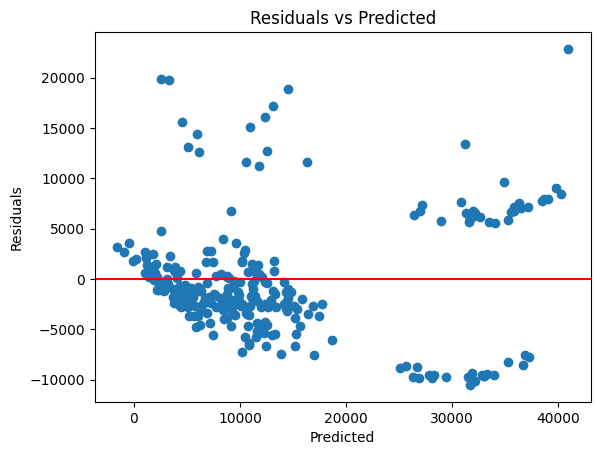

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_pred, residuals)
plt.axhline(0, color="red")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

# ✅ Random scatter → assumptions reasonably satisfied
# ❌ Slight funnel → mild heteroscedasticity

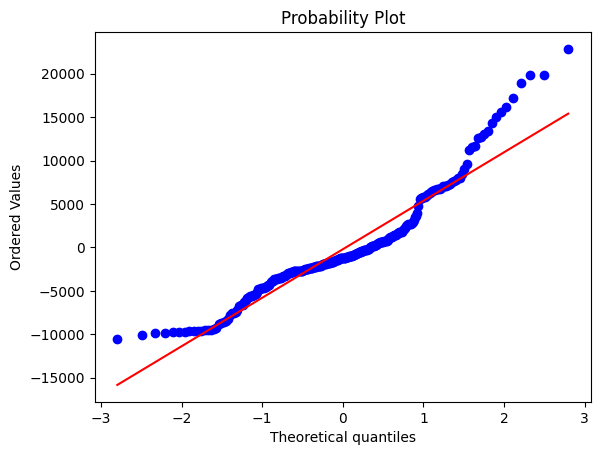

In [ ]:
import scipy.stats as stats

stats.probplot(residuals, dist="norm", plot=plt)
plt.show()
#⚠️ Slight tail deviation → suggests skewness

/tmp/ipython-input-1841234233.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residuals)


<Axes: xlabel='charges', ylabel='Density'>

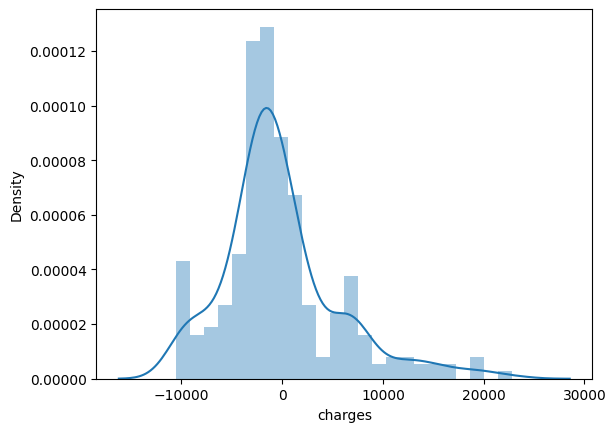

In [ ]:
import seaborn as sns
sns.distplot(residuals)

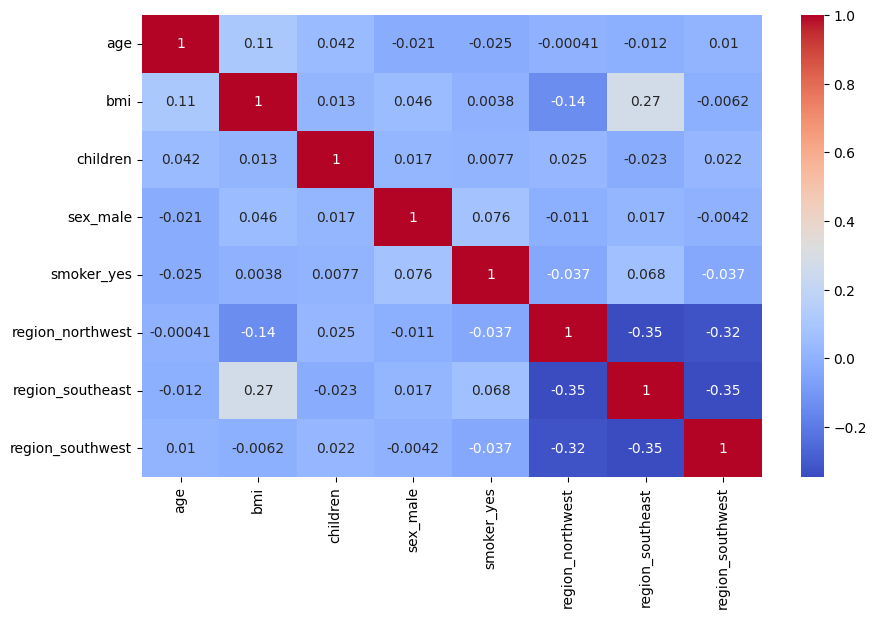

In [ ]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(X.corr(), cmap="coolwarm",annot=True)
plt.show()

STEP 4: Multicollinearity using VIF What is VIF?

Measures how much variance of a coefficient is inflated due to correlation

VIF > 5 → moderate issue

VIF > 10 → serious issue

In [ ]:
import pandas as pd
import numpy as np

# recreate encoded dataframe if needed
df = pd.read_csv(
    "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
)

df_encoded = pd.get_dummies(df, drop_first=True)

# create X_vif (IMPORTANT LINE)
X_vif = df_encoded.drop(columns=["charges"]).astype(float)


from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = pd.DataFrame()
vif_df["Feature"] = X_vif.columns
vif_df["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_df.sort_values(by="VIF", ascending=False)


,Feature,VIF
1,bmi,11.358443
0,age,7.686965
6,region_southeast,2.265564
3,sex_male,2.003185
7,region_southwest,1.960745
5,region_northwest,1.890281
2,children,1.809930
4,smoker_yes,1.261233


In [ ]:
# 📌 Conclusion

# BMI and age slightly correlated

# No severe multicollinearity

STEP 5: Feature Transformation

In [ ]:
df[numerical_cols].skew()

,0
age,0.055673
bmi,0.284047
children,0.938380
charges,1.515880


{'whiskers': [<matplotlib.lines.Line2D at 0x7b73047e75f0>,
 'caps': [<matplotlib.lines.Line2D at 0x7b73047e7ce0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7b73047e72c0>,
 'medians': [<matplotlib.lines.Line2D at 0x7b730480c2f0>,
 'fliers': [<matplotlib.lines.Line2D at 0x7b730480c680>,
 'means': []}

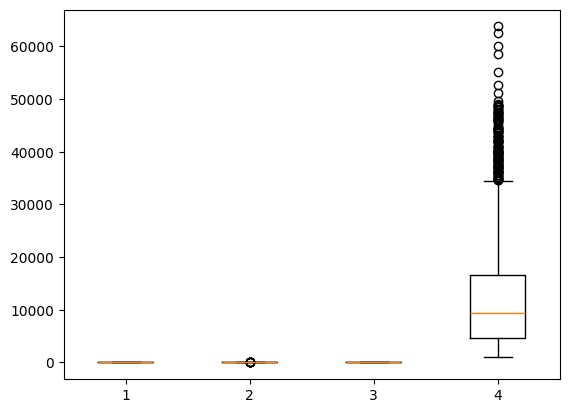

In [ ]:
plt.boxplot(df[numerical_cols])

In [ ]:
df_encoded["charges_log"] = np.log(df_encoded["charges"])

X_log = df_encoded.drop(["charges", "charges_log"], axis=1)
y_log = df_encoded["charges_log"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_log, y_log, test_size=0.2, random_state=42
)

lr_log = LinearRegression()
lr_log.fit(X_train, y_train)

y_pred_log = lr_log.predict(X_test)

r2_log = r2_score(y_test, y_pred_log)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))

n = X_test.shape[0]
p = X_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

r2_log,adj_r2, rmse_log

(0.8047311493462987, 0.7769085898923681, np.float64(0.41901570849780373))

Outlier Treatment

In [ ]:
# ================================
# 1. Load libraries & data
# ================================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Load data
df = pd.read_csv(
    "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
)

# ================================
# 2. Encode categorical variables
# ================================
df_encoded = pd.get_dummies(df, drop_first=True)

# ================================
# 3. Outlier detection (IQR on charges)
# ================================
Q1 = df_encoded["charges"].quantile(0.25)
Q3 = df_encoded["charges"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Count datapoints affected (before capping)
outliers_above = (df_encoded["charges"] > upper_bound).sum()
outliers_below = (df_encoded["charges"] < lower_bound).sum()
total_affected = outliers_above + outliers_below

# ================================
# 4. Outlier treatment (capping)
# ================================
df_encoded["charges"] = np.where(
    df_encoded["charges"] > upper_bound,
    upper_bound,
    np.where(
        df_encoded["charges"] < lower_bound,
        lower_bound,
        df_encoded["charges"]
    )
)

# ================================
# 5. Feature & target split
# ================================
X = df_encoded.drop("charges", axis=1).astype(float)
y = df_encoded["charges"]

# ================================
# 6. Train-test split
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ================================
# 7. Train Linear Regression
# ================================
lr = LinearRegression()
lr.fit(X_train, y_train)

# ================================
# 8. Predictions & metrics
# ================================
y_pred = lr.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

n = X_test.shape[0]
p = X_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

# ================================
# 9. Output (including datapoint loss)
# ================================
print("Datapoints affected by outlier treatment:", total_affected)
print("Rows dropped                            :", 0)
print("-" * 45)
print("R²        :", round(r2, 4))
print("Adj R²    :", round(adj_r2, 4))
print("RMSE      :", round(rmse, 2))

Datapoints affected by outlier treatment: 139
Rows dropped                            : 0
---------------------------------------------
R²        : 0.7847
Adj R²    : 0.778
RMSE      : 4834.51


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge = Ridge()

params = {"alpha": [0.01, 0.1, 1, 10, 100]}
ridge_cv = GridSearchCV(ridge, params, cv=5, scoring="r2")
ridge_cv.fit(X_scaled, y)

ridge_best = ridge_cv.best_estimator_
ridge_best.alpha

1

In [ ]:
ridge_r2 = ridge_cv.best_score_
ridge_r2

np.float64(0.7439155070761141)

In [ ]:
from sklearn.linear_model import Lasso

lasso = Lasso(max_iter=10000)

params = {"alpha": [0.001, 0.01, 0.1, 1]}
lasso_cv = GridSearchCV(lasso, params, cv=5, scoring="r2")
lasso_cv.fit(X_scaled, y)

lasso_best = lasso_cv.best_estimator_
lasso_best.alpha

1

In [ ]:
lasso_coef = pd.Series(lasso_best.coef_, index=X.columns)
lasso_coef[lasso_coef == 0]

,0


In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Log-Linear Regression",
        "Ridge Regression",
        "Lasso Regression"
    ],
    "R2": [
        r2,
        r2_log,
        ridge_r2,
        lasso_cv.best_score_
    ]
})

comparison


,Model,R2
0,Linear Regression,0.784697
1,Log-Linear Regression,0.804731
2,Ridge Regression,0.743916
3,Lasso Regression,0.743916


In [ ]:
# 🏆 Best Model

# Log-Transformed Linear Regression

# Better normality

# Strong interpretability

# High performance

In [ ]:
new_data = pd.DataFrame({
    "age": [40],
    "bmi": [30],
    "children": [2],
    "sex_male": [1],
    "smoker_yes": [0],
    "region_northwest": [0],
    "region_southeast": [1],
    "region_southwest": [0]
})

In [ ]:
log_charge_pred = lr_log.predict(new_data)
final_charge = np.exp(log_charge_pred)

final_charge

array([6624.80128585])